In [22]:
import keras
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

import platform

# 한글 폰트 설정
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

# 마이너스 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

In [23]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

In [24]:
# 2. 클래스 이름 정의 (CIFAR-10 공식 순서)
classes = [
    "비행기", "자동차", "새", "고양이", "사슴",
    "개", "개구리", "말", "배", "트럭",
]

# 3. 데이터 차원 확인
print("==== 데이터 구조 확인 ====")
print(
    f"Train 이미지 차원: {x_train.shape}"
)  # (50000, 32, 32, 3) -> 5만장, 32x32 해상도, RGB 3채널
print(f"Train 라벨 차원: {y_train.shape}")  # (50000, 1)
print(f"Test 이미지 차원: {x_test.shape}")  # (10000, 32, 32, 3)
print(f"테스트 데이터 비율: {len(x_test) / (len(x_train) + len(x_test)) * 100:.1f}%")
print(f"픽셀 최솟값: {x_train.min()}, 최댓값: {x_train.max()}")

==== 데이터 구조 확인 ====
Train 이미지 차원: (50000, 32, 32, 3)
Train 라벨 차원: (50000, 1)
Test 이미지 차원: (10000, 32, 32, 3)
테스트 데이터 비율: 16.7%
픽셀 최솟값: 0, 최댓값: 255


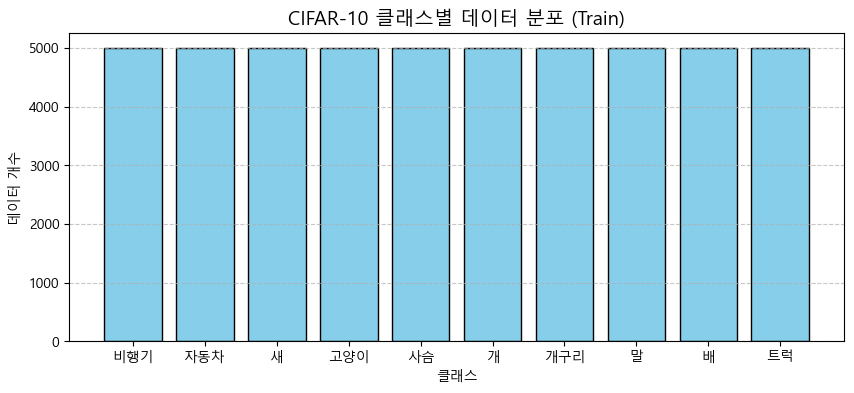

클래스별 개수: {'비행기': np.int64(5000), '자동차': np.int64(5000), '새': np.int64(5000), '고양이': np.int64(5000), '사슴': np.int64(5000), '개': np.int64(5000), '개구리': np.int64(5000), '말': np.int64(5000), '배': np.int64(5000), '트럭': np.int64(5000)}


In [25]:
# 클래스별 빈도수 계산
unique, counts = np.unique(y_train, return_counts=True)

# 시각화
plt.figure(figsize=(10, 4))
plt.bar(classes, counts, color="skyblue", edgecolor="black")
plt.title("CIFAR-10 클래스별 데이터 분포 (Train)", fontsize=14)
plt.xlabel("클래스")
plt.ylabel("데이터 개수")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

print("클래스별 개수:", dict(zip(classes, counts)))

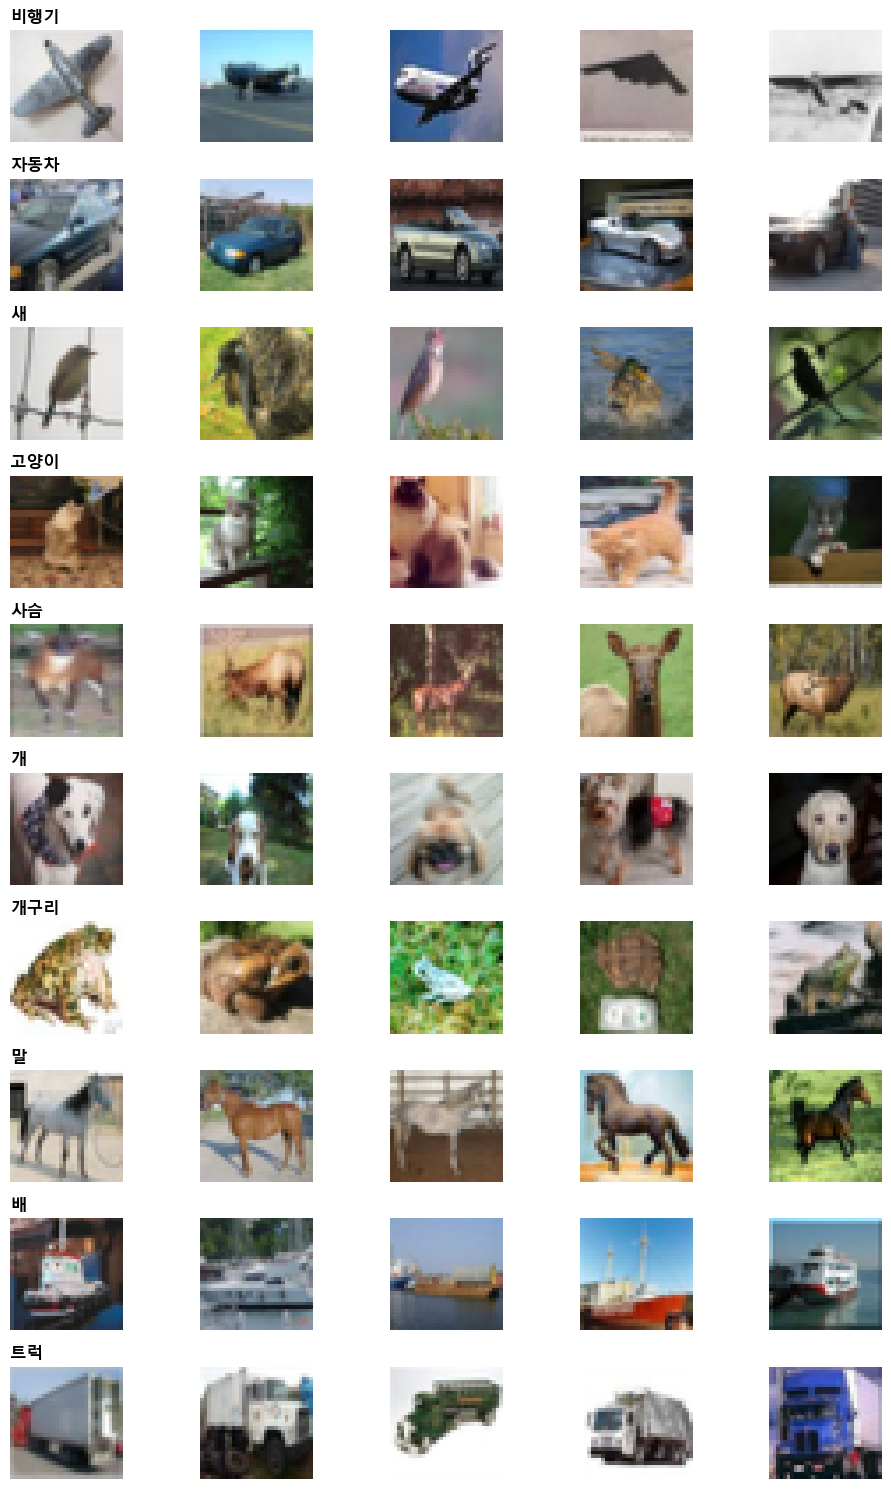

In [26]:
num_classes = 10
samples_per_class = 5

# 10행 5열의 서브플롯 생성
fig, axes = plt.subplots(num_classes, samples_per_class, figsize=(10, 15))

for cluster_idx, class_name in enumerate(classes):
    # 해당 클래스의 인덱스만 추출
    idx = np.flatnonzero(y_train == cluster_idx)
    # 무작위로 5개 선택
    rand_idx = np.random.choice(idx, samples_per_class, replace=False)

    for i, img_idx in enumerate(rand_idx):
        ax = axes[cluster_idx, i]
        ax.imshow(x_train[img_idx])
        ax.axis("off")

        # 첫 번째 열에만 클래스 이름 표시
        if i == 0:
            ax.set_title(class_name, loc="left", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [27]:
y_train = y_train.reshape(-1)
y_test = y_test.reshape(-1)

In [28]:
y_train.shape, y_test.shape

((50000,), (10000,))

In [29]:
train_scaled = x_train / 255.0
test_scaled = x_test / 255.0

In [30]:
train_scaled.shape, test_scaled.shape

((50000, 32, 32, 3), (10000, 32, 32, 3))

In [31]:
model = keras.Sequential([
    keras.layers.Input(shape=(32,32,3)), # 입력층
    # Layer 1
    keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    keras.layers.MaxPool2D(2),
    # Layer 2 
    keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
    keras.layers.MaxPool2D(2),

    keras.layers.Flatten(), # 평탄화 
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(10, activation='softmax') # 출력층
])

In [32]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │       409,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 430,102 (1.64 MB)

 Trainable params: 430,102 (1.64 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model.compile(
    optimizer='adam',
    loss=keras.losses.sparse_categorical_crossentropy,
    metrics=['accuracy'],
    jit_compile=False
)

In [34]:
checkpoint = keras.callbacks.ModelCheckpoint('challenge-best-model.keras', save_best_only=True)
early_stopping = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

In [35]:
history = model.fit(train_scaled, y_train, epochs=20,
                    validation_split=0.2, callbacks=[checkpoint, early_stopping])

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.3867 - loss: 1.6736 - val_accuracy: 0.5467 - val_loss: 1.2991
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5204 - loss: 1.3345 - val_accuracy: 0.6146 - val_loss: 1.1207
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.5743 - loss: 1.1915 - val_accuracy: 0.6318 - val_loss: 1.0504
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6080 - loss: 1.1004 - val_accuracy: 0.6568 - val_loss: 0.9762
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6348 - loss: 1.0308 - val_accuracy: 0.6760 - val_loss: 0.9423
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6520 - loss: 0.9747 - val_accuracy: 0.6872 - val_loss: 0.9109
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6707 - loss: 0.9250 - val_accuracy: 0.6853 - val_loss: 0.9040
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6845 - loss: 0.8866 - 

In [36]:
print('최고 val_accuracy : ', max(history.history['val_accuracy']))

최고 val_accuracy :  0.6872000098228455


In [37]:
test_loss, test_acc = model.evaluate(test_scaled, y_test)

print("test_loss:", test_loss)
print("test_accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6817 - loss: 0.9070
test_loss: 0.9069722890853882
test_accuracy: 0.6816999912261963




### 신경망 깊이 더 추가

In [38]:
deep_model = keras.Sequential(
    [
        keras.layers.Input(shape=(32, 32, 3)),
        # Block 1
        keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
        keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
        keras.layers.MaxPool2D(2),
        # Block 2
        keras.layers.Conv2D(64, 3, activation="relu", padding="same"),
        keras.layers.Conv2D(64, 3, activation="relu", padding="same"),
        keras.layers.MaxPool2D(2),
        # Block 3
        keras.layers.Conv2D(128, 3, activation="relu", padding="same"),
        keras.layers.MaxPool2D(2),
        keras.layers.Flatten(),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.4),
        keras.layers.Dense(10, activation="softmax"),
    ]
)

deep_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,986 (1.54 MB)

 Trainable params: 402,986 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
deep_model.compile(
    optimizer="adam",
    loss=keras.losses.sparse_categorical_crossentropy,
    metrics=["accuracy"],
    jit_compile=False,
)

In [40]:
checkpoint = keras.callbacks.ModelCheckpoint(
    "deep-challenge-best-model.keras", save_best_only=True
)

early_stopping = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

In [41]:
history_deep = deep_model.fit(
    train_scaled,
    y_train,
    epochs=20,
    validation_split=0.2,
    callbacks=[checkpoint, early_stopping],
)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.3910 - loss: 1.6546 - val_accuracy: 0.5139 - val_loss: 1.3331
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.5774 - loss: 1.1889 - val_accuracy: 0.6316 - val_loss: 1.0593
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.6579 - loss: 0.9764 - val_accuracy: 0.7103 - val_loss: 0.8297
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.7050 - loss: 0.8447 - val_accuracy: 0.7199 - val_loss: 0.8030
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 23s 19ms/step - accuracy: 0.7396 - loss: 0.7515 - val_accuracy: 0.7236 - val_loss: 0.7960
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.7659 - loss: 0.6730 - val_accuracy: 0.7359 - val_loss: 0.7992
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 23s 19ms/step - accuracy: 0.7856 - loss: 0.6126 - val_accuracy: 0.7361 - val_loss: 0.7770
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.8055 -

In [42]:
print("Deep CNN 최고 val_accuracy:", max(history_deep.history["val_accuracy"]))

deep_test_loss, deep_test_acc = deep_model.evaluate(test_scaled, y_test)

print("deep_test_loss:", deep_test_loss)
print("deep_test_accuracy:", deep_test_acc)

Deep CNN 최고 val_accuracy: 0.7652999758720398
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7547 - loss: 0.7627
deep_test_loss: 0.7626895308494568
deep_test_accuracy: 0.7547000050544739


In [43]:
import pandas as pd

result_df = pd.DataFrame(
    {
        "모델": ["기본 CNN", "Deep CNN"],
        "구조": [
            "Conv2D(32) → Conv2D(64)",
            "Conv2D(32×2) → Conv2D(64×2) → Conv2D(128)",
        ],
        "파라미터 수": [model.count_params(), deep_model.count_params()],
        "최고 val_accuracy": [
            round(max(history.history["val_accuracy"]), 4),
            round(max(history_deep.history["val_accuracy"]), 4),
        ],
        "test_accuracy": [round(test_acc, 4), round(deep_test_acc, 4)],
    }
)

result_df

,모델,구조,파라미터 수,최고 val_accuracy,test_accuracy
0,기본 CNN,Conv2D(32) → Conv2D(64),430102,0.6872,0.6817
1,Deep CNN,Conv2D(32×2) → Conv2D(64×2) → Conv2D(128),402986,0.7653,0.7547
